Upload & Extract Dataset

In [4]:
from google.colab import files
uploaded = files.upload()  # Upload your test.zip or dataset.zip


Saving test.zip to test.zip


In [5]:
import zipfile
import os

with zipfile.ZipFile("test.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/dataset")


Import Libraries

In [6]:
import os
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


Data Preprocessing

In [7]:
# Transformations
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

# Load datasets
train_dataset = ImageFolder(root="/content/dataset", transform=transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# Class names
class_names = train_dataset.classes
print("Classes:", class_names)


Classes: ['test']


Define the CNN Model

In [8]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.fc1 = nn.Linear(32 * 32 * 32, 128)
        self.fc2 = nn.Linear(128, num_classes)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(-1, 32 * 32 * 32)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Instantiate
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN(num_classes=len(class_names)).to(device)


Train the Model

In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
epochs = 10
for epoch in range(epochs):
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader):.4f}")


Epoch 1/10, Loss: 0.0000
Epoch 2/10, Loss: 0.0000
Epoch 3/10, Loss: 0.0000
Epoch 4/10, Loss: 0.0000
Epoch 5/10, Loss: 0.0000
Epoch 6/10, Loss: 0.0000
Epoch 7/10, Loss: 0.0000
Epoch 8/10, Loss: 0.0000
Epoch 9/10, Loss: 0.0000
Epoch 10/10, Loss: 0.0000


Save the Model

In [11]:
torch.save(model.state_dict(), "cnn_model.pth")


Predict Using the Trained CNN

In [12]:
# Load the model again (same architecture)
model = SimpleCNN(num_classes=len(class_names))
model.load_state_dict(torch.load("cnn_model.pth"))
model.to(device)
model.eval()  # Set to evaluation mode


SimpleCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=32768, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=1, bias=True)
  (relu): ReLU()
)

Split Image Dataset into 80:20

In [13]:
from google.colab import files
uploaded = files.upload()  # Upload a test image (e.g., test.jpg)


Saving test.zip to test (1).zip


Unzip Dataset

In [33]:
from zipfile import ZipFile

zip_path = "/content/test.zip"
extract_path = "/content/dataset"

with ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Dataset extracted.")


✅ Dataset extracted.


Split into Train and Test (80:20)

In [34]:
import os
import shutil
import random
from sklearn.model_selection import train_test_split

original_data_dir = "/content/dataset/test"
base_dir = "/content/split_dataset"
train_dir = os.path.join(base_dir, "train")
test_dir = os.path.join(base_dir, "test")

os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

# Split function
def split_data():
    for emotion in os.listdir(original_data_dir):
        emotion_dir = os.path.join(original_data_dir, emotion)
        if not os.path.isdir(emotion_dir):
            continue

        images = os.listdir(emotion_dir)
        train_imgs, test_imgs = train_test_split(images, test_size=0.2, random_state=42)

        train_emotion_dir = os.path.join(train_dir, emotion)
        test_emotion_dir = os.path.join(test_dir, emotion)
        os.makedirs(train_emotion_dir, exist_ok=True)
        os.makedirs(test_emotion_dir, exist_ok=True)

        for img in train_imgs:
            src = os.path.join(emotion_dir, img)
            dst = os.path.join(train_emotion_dir, img)
            shutil.copyfile(src, dst)

        for img in test_imgs:
            src = os.path.join(emotion_dir, img)
            dst = os.path.join(test_emotion_dir, img)
            shutil.copyfile(src, dst)

    print("✅ Dataset split into train and test folders.")

split_data()


✅ Dataset split into train and test folders.


Setup ImageDataGenerator for Grayscale Images

In [35]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Image size and paths
img_size = (48, 48)
batch_size = 64
train_path = '/content/split_dataset/train'
test_path = '/content/split_dataset/test'

# Preprocessing for grayscale images
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Flow from directory
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=img_size,
    color_mode='grayscale',
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=img_size,
    color_mode='grayscale',
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)


Found 5739 images belonging to 7 classes.
Found 1439 images belonging to 7 classes.


Build a CNN Model for Emotion Classification

In [36]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

model = Sequential([
    Conv2D(64, (3,3), activation='relu', input_shape=(48, 48, 1), padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(train_generator.num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 48, 48, 64)          │             640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 48, 48, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 24, 24, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 24, 24, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 24, 24, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 24, 24, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 12, 12, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 12, 12, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 12, 12, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 12, 12, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 6, 6, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 6, 6, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 9216)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       1,179,776 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 7)                   │             903 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,552,135 (5.92 MB)

 Trainable params: 1,551,239 (5.92 MB)

 Non-trainable params: 896 (3.50 KB)

Train the CNN Model

In [37]:
history = model.fit(
    train_generator,
    epochs=20,
    validation_data=test_generator
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 146s 2s/step - accuracy: 0.2093 - loss: 2.7446 - val_accuracy: 0.0160 - val_loss: 19.7969
Epoch 2/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 145s 2s/step - accuracy: 0.2404 - loss: 1.8782 - val_accuracy: 0.2481 - val_loss: 2.9439
Epoch 3/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 198s 2s/step - accuracy: 0.2514 - loss: 1.8352 - val_accuracy: 0.2467 - val_loss: 1.8285
Epoch 4/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.2438 - loss: 1.8081 - val_accuracy: 0.2460 - val_loss: 1.7871
Epoch 5/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 135s 2s/step - accuracy: 0.2519 - loss: 1.7762 - val_accuracy: 0.2557 - val_loss: 1.7605
Epoch 6/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - accuracy: 0.2713 - loss: 1.7526 - val_accuracy: 0.2794 - val_loss: 1.7470
Epoch 7/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 137s 2s/step - accuracy: 0.2664 - loss: 1.7366 - val_accuracy: 0.2981 - val_loss: 1.7254
Epoch 8/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 138s 2s/step - accuracy: 0.2831 - loss: 1.7246 - val_accuracy: 0.3065 - 

In [38]:
# Evaluate on test data
loss, accuracy = model.evaluate(test_generator)
print(f"🧪 Test Accuracy: {accuracy*100:.2f}%")


23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 315ms/step - accuracy: 0.2181 - loss: 1.7201
🧪 Test Accuracy: 32.80%


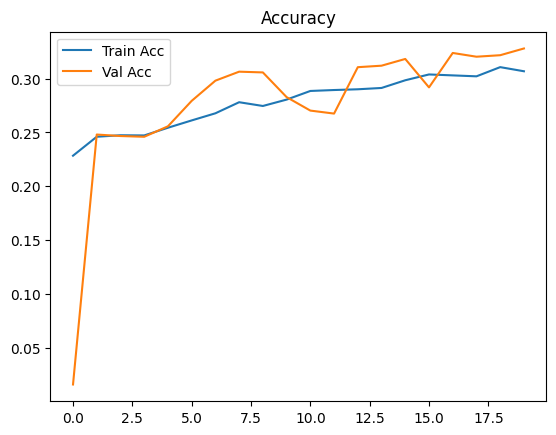

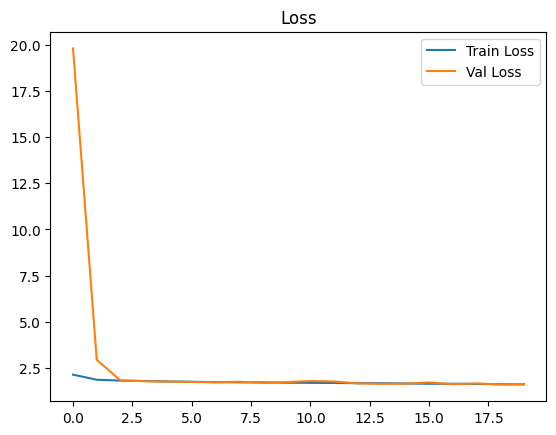

In [40]:
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


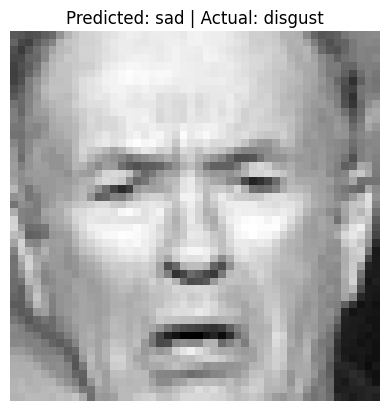

In [42]:
import random
from tensorflow.keras.preprocessing import image
import numpy as np

# Pick one random image from the test set
emotion_labels = list(test_generator.class_indices.keys())
test_folder = os.path.join(base_dir, "test")
chosen_emotion = random.choice(emotion_labels)

img_folder = os.path.join(test_folder, chosen_emotion)
img_name = random.choice(os.listdir(img_folder))
img_path = os.path.join(img_folder, img_name)

# Load and preprocess image
img = image.load_img(img_path, target_size=img_size, color_mode='grayscale')
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)
pred_label = emotion_labels[np.argmax(pred)]

# Show image and prediction
img_array_squeezed = np.squeeze(img_array)  # Squeeze the NumPy array
plt.imshow(img_array_squeezed, cmap='gray')  # Use the squeezed array for display
plt.title(f"Predicted: {pred_label} | Actual: {chosen_emotion}")
plt.axis('off')
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


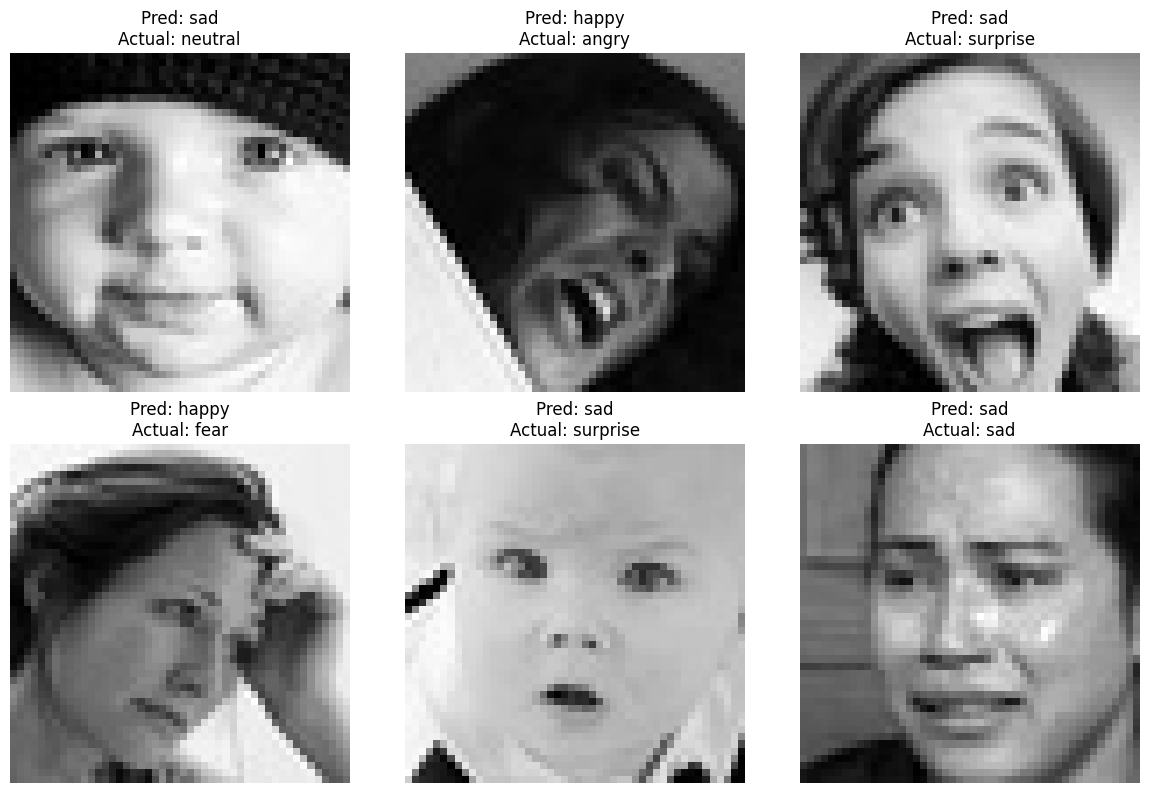

In [44]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import numpy as np # Import numpy for array manipulation

# Get class labels
emotion_labels = list(test_generator.class_indices.keys())
test_folder = os.path.join(base_dir, "test")

# Create a 2x3 grid
plt.figure(figsize=(12, 8))

for i in range(6):
    chosen_emotion = random.choice(emotion_labels)
    img_folder = os.path.join(test_folder, chosen_emotion)
    img_name = random.choice(os.listdir(img_folder))
    img_path = os.path.join(img_folder, img_name)

    # Load and preprocess
    img = image.load_img(img_path, target_size=img_size, color_mode='grayscale')
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    pred = model.predict(img_array)
    pred_label = emotion_labels[np.argmax(pred)]

    # Plot
    plt.subplot(2, 3, i + 1)
    # Convert PIL Image to NumPy array and then squeeze
    img_array_squeezed = np.squeeze(img_array)
    plt.imshow(img_array_squeezed, cmap='gray')
    plt.title(f"Pred: {pred_label}\nActual: {chosen_emotion}")
    plt.axis('off')

plt.tight_layout()
plt.show()

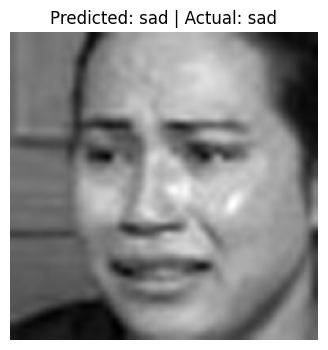

In [45]:
import cv2

# Read and upscale the image
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

# Resize for better viewing (e.g. 5x bigger)
upscaled_img = cv2.resize(img, (240, 240), interpolation=cv2.INTER_CUBIC)

# Display using matplotlib
plt.figure(figsize=(4, 4))
plt.imshow(upscaled_img, cmap='gray')
plt.title(f"Predicted: {pred_label} | Actual: {chosen_emotion}")
plt.axis('off')
plt.show()
